``ModelEvaluatorPlot.compare`` draws the paired comparison from ``ModelEvaluator.eval`` as signed delta bars with CI whiskers and significance stars. First, the dataset, feature matrix, evaluation, and comparison:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + a small feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix X
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

me = aa.ModelEvaluator(models=["rf", "svm", "log_reg"], random_state=42, verbose=False)
df_eval = me.run(X, labels, n_rounds=3)
df_compare = me.eval(metric="mcc")

/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programming/1Packages/aaanalysis/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/stephanbreimann/Programm

Plot the comparison table with a ``figsize``, positive/negative ``colors``, and a significance level ``alpha``:

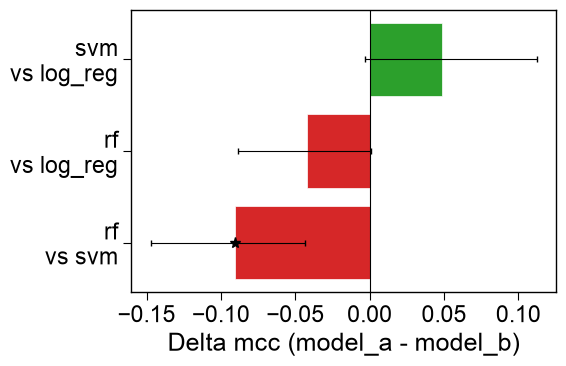

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
fig, ax = aa.ModelEvaluatorPlot.compare(df_eval=df_compare, figsize=(6, 4),
                                        colors=["tab:green", "tab:red"], alpha=0.05)
plt.tight_layout()
plt.show()